# 20. Aggregation: Growth by Random Walk

This book opened with a single random walk that drew a line. Today we release ten thousand random walkers and give them one extra rule: when you touch something frozen, freeze too. Out of that sentence grows frost.

## Today's destination

A dendrite grown from a single frozen cell by eighteen thousand random walkers, each wandering in from the cold until it touched the cluster and stuck. The color is time: deep blue where the frost is oldest, ice-white at the youngest tips. Nobody drew these branches; they are what diffusion looks like when it is not allowed to let go. By the end of today you can grow them at will, and measure their fractal dimension while you are at it.

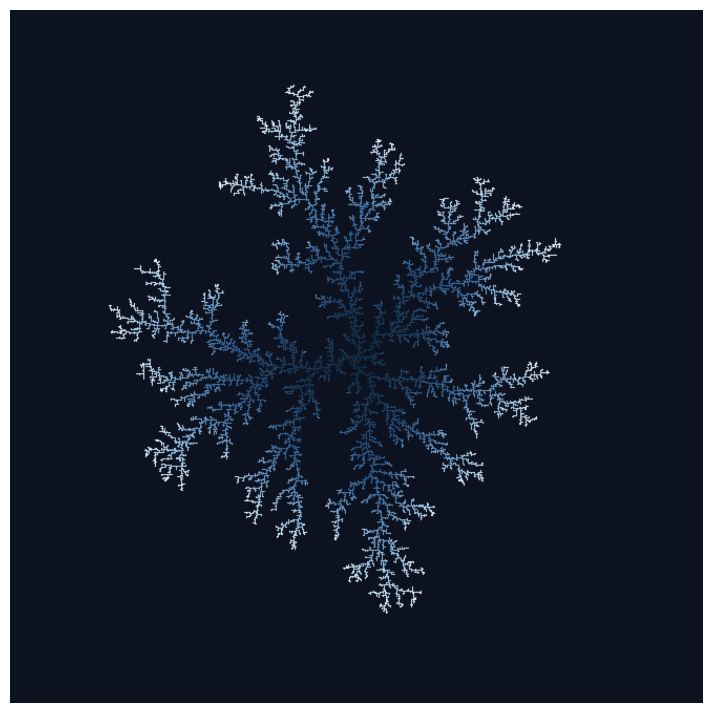

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch20_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(9, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: nature's drawings of chance

On 15 January 1885, a Vermont farmer named **Wilson Bentley** did something nobody had managed before: he photographed a single snow crystal through a microscope, before it could melt. He spent the next forty-six winters photographing more than five thousand of them, and the popular claim that no two snowflakes are alike traces to him. His life's work appeared as *Snow Crystals* (1931), assembled with the physicist W. J. Humphreys, more than 2,400 photographs <a class="cite" href="#ref-bentley1931">(Bentley and Humphreys 1931)</a>; Bentley died that December, weeks after the book was printed <a class="cite" href="#ref-blanchard1998">(Blanchard 1998)</a>. Open it and the pull is instant: endless variations of one branching idea, a natural *catalogue raisonné* of frozen chance.

Nature draws the same figure in stone. **Manganese dendrites**, branching black mineral deposits on limestone (the Solnhofen quarries of Bavaria are the classic source), look so convincingly like pressed ferns that they were long mistaken for fossil plants; geologists call them the textbook **pseudofossil** (Scheinfossil) (<a class="cite" href="#ref-chopard1991">Chopard et al. 1991</a>; <a class="cite" href="#ref-wilson2013">Wilson 2013</a>). A book as full of ferns as this one cannot resist a mineral that impersonates them. And electricity draws it too: in 1777 the Göttingen physicist **Georg Christoph Lichtenberg** noticed dust settling on a charged resin plate in branching star patterns, the discharge recording its own portrait. **Lichtenberg figures**, today made by firing electron beams into acrylic blocks, count as the earliest images of electricity <a class="cite" href="#ref-takahashi1979">(Takahashi 1979)</a>, and they look like winter on a windowpane.

Snowflake arms, mineral ferns, frozen lightning: why does matter keep drawing the *same* picture? In 1981 the physicists **Thomas Witten** and **Leonard Sander** proposed an answer of astonishing simplicity, **diffusion-limited aggregation** (DLA) <a class="cite" href="#ref-witten1981">(Witten and Sander 1981)</a>: particles wander randomly (that is diffusion), and stick where they first touch (that is aggregation). Nothing else. The model draws branches because branches are self-reinforcing: whatever sticks out catches the next wanderer, and the fjords between branches starve. A real snow crystal is not pure DLA (its six-fold symmetry comes from the ice lattice underneath; <a class="cite" href="#ref-libbrecht2005">Libbrecht 2005</a>), but its feathery arms grow by the same logic, and so do zinc deposits in electrochemical cells, viscous fingers in oil, and the branching of dielectric breakdown (<a class="cite" href="#ref-matsushita1984">Matsushita et al. 1984</a>; <a class="cite" href="#ref-ball2009">Ball 2009</a>).

For us the model closes two circles. The random walker of chapter 1, who drew our very first line, returns as a *population*, and their frozen sum is a drawing no walker made. And chapter 8's Pollock affair returns with teeth: Witten and Sander's clusters have a *measurable* fractal dimension, about 1.71, and by the end of this chapter you will measure one yourself, with the same log-log trick Richard Taylor aimed at *Blue Poles* <a class="cite" href="#ref-taylor1999">(Taylor et al. 1999)</a>.

## The rule

A DLA world needs only three ingredients:

1. **A seed.** One frozen cell in the middle of an empty grid.
2. **A walker.** A particle doing chapter 1's random walk: each tick, one step up, down, left or right, chosen by chance.
3. **The sticking rule.** The moment the walker stands next to a frozen cell, it freezes too, forever.

That is the whole physics. Watch one walker live through it:

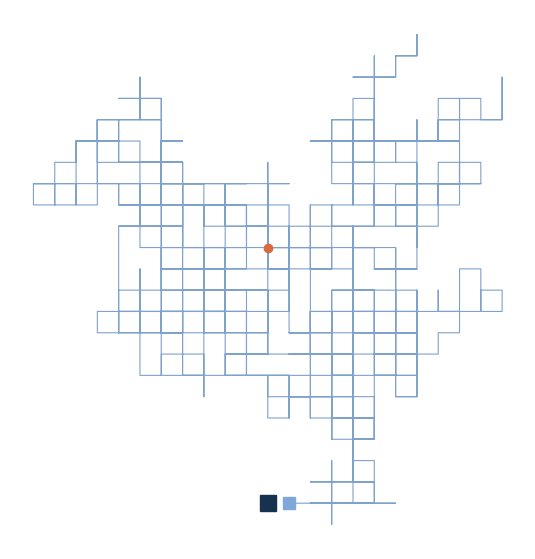

1128 steps from birth (orange) to freezing (pale blue, beside the seed)


In [2]:
# one walker, the whole idea: wander until you touch the seed, then freeze
import numpy as np

rng = np.random.default_rng(5)
moves = [(1, 0), (-1, 0), (0, 1), (0, -1)]   # down, up, right, left
seed_row, seed_col = 0, 0                    # the frozen seed, at the origin
row, col = 12, 0                             # the walker starts out in the cold
path = [(row, col)]
while abs(row - seed_row) + abs(col - seed_col) > 1:   # not yet touching
    dr, dc = moves[rng.integers(0, 4)]
    row, col = row + dr, col + dc
    path.append((row, col))

path = np.array(path)
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(path[:, 1], path[:, 0], lw=0.8, color="#5E8BC0", alpha=0.8)
ax.plot(seed_col, seed_row, "s", color="#16324F", markersize=12)
ax.plot(path[0, 1], path[0, 0], "o", color="#D96C3F")
ax.plot(path[-1, 1], path[-1, 0], "s", color="#7FA8D9", markersize=8)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
print(f"{len(path)} steps from birth (orange) to freezing (pale blue, beside the seed)")

More than a thousand steps of drunken scribble for one moment of contact. That inefficiency is the point (the wandering *is* the diffusion, and the starved fjords below depend on it), but simulated naively it is also the problem: most of a walker's life is spent far away, touching nothing. Two standard tricks make the simulation honest *and* fast, and both are about geometry, not physics:

- **The birth ring.** A walker arriving from infinitely far away is equally likely to arrive from any direction, so we may as well create it on a circle just outside the cluster, radius $R + 5$.
- **The kill ring.** A walker that strays far outside that circle would wander an enormous time before touching anything again (a two-dimensional random walk always comes back eventually, but "eventually" is the problem), and when it finally returned, its arrival point would again be spread evenly around the frost; so we delete it and spawn a fresh walker on the birth ring instead of waiting out its exile.

And one dial we add for later: **stickiness** (Haftwahrscheinlichkeit), the probability that a touch actually freezes. At stickiness 1.0 every touch binds; at 0.3 walkers bounce along the branches a while before catching, and you will see what that does to the anatomy.

To run *thousands* of walkers at once we keep them as an `(n, 2)` array, chapter 19's agent idiom, and move them all in one line: `STEPS[rng.integers(0, 4, n)]` looks a random row per walker out of a four-row table of moves, the same table-lookup move as chapter 10's particles reading angles from a grid. The cluster itself lives on a boolean grid, and the sticking test needs its *neighbors*: `binary_dilation` from scipy grows every frozen cell by one ring, producing the grid of landing pads.

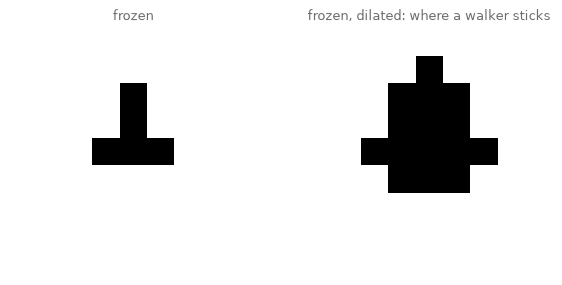

In [3]:
# the two grids of the fast version: the frozen cells, and their landing pads
from scipy.ndimage import binary_dilation

STEPS = np.array([(0, 1), (0, -1), (1, 0), (-1, 0)])   # the four lattice moves

demo = np.zeros((9, 9), bool)
demo[4, 3:6] = True
demo[2:5, 4] = True
pads = binary_dilation(demo)     # True on every cell touching a frozen cell

fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
axes[0].imshow(demo, cmap="gray_r")
axes[0].set_title("frozen", fontsize=9, color="#6B6B6B")
axes[1].imshow(pads, cmap="gray_r")
axes[1].set_title("frozen, dilated: where a walker sticks", fontsize=9,
                  color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

## The grower

Now the engine, in one function. It tracks the cluster's radius as it grows, keeps a crowd of concurrent walkers proportional to that radius (a genuinely dilute simulation would use one walker at a time, as in our first cell; a modest crowd changes nothing visible and is hundreds of times faster), records each frozen particle's **deposition index** so we can color by age later, and stops when the requested number of particles has frozen or the frost reaches the edge of the grid. At thirty-odd lines it is the longest function of the chapter, but every line is one sentence of the rules above.

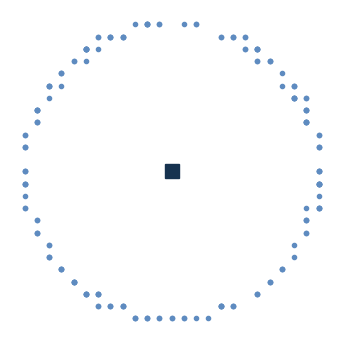

In [4]:
# the birth ring: walkers appear on a circle just outside the frost
def ring_spawn(rng, center, radius, m):
    angles = rng.uniform(0, 2 * np.pi, m)
    rows = np.round(center + radius * np.sin(angles)).astype(int)
    cols = np.round(center + radius * np.cos(angles)).astype(int)
    return np.column_stack([rows, cols])          # glue into an (m, 2) array

demo_rng = np.random.default_rng(16)
births = ring_spawn(demo_rng, 0, 12, 200)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot(0, 0, "s", color="#16324F", markersize=10)
ax.plot(births[:, 1], births[:, 0], "o", color="#5E8BC0", markersize=3)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

Two hundred births on the ring (chapter 3's circle trigonometry, as ever). Now the engine itself:

In [5]:
# the DLA engine: spawn on the birth ring, wander, stick, repeat
def grow_dla(grid_size=480, n_particles=10000, stickiness=1.0, crowd=4, seed=16,
             seed_cells=None):
    rng = np.random.default_rng(seed)
    center, limit = grid_size // 2, grid_size // 2 - 2
    if seed_cells is None:
        seed_cells = (np.array([center]), np.array([center]))
    occupied = np.zeros((grid_size, grid_size), bool)
    occupied[seed_cells] = True
    age = np.full((grid_size, grid_size), -1)     # -1 empty, else deposition index
    age[seed_cells] = 0
    sticky = binary_dilation(occupied)
    radius = float(np.hypot(seed_cells[0] - center, seed_cells[1] - center).max()) + 1
    walkers = ring_spawn(rng, center, radius + 5, 8)
    count = len(seed_cells[0])
    while count < n_particles and radius < limit - 6:
        wanted = int(min(3000, max(8, crowd * radius)))
        if wanted > len(walkers):
            walkers = np.vstack([walkers, ring_spawn(rng, center, radius + 5,
                                                     wanted - len(walkers))])
        walkers += STEPS[rng.integers(0, 4, len(walkers))]
        rows, cols = walkers[:, 0], walkers[:, 1]
        lost = np.hypot(rows - center, cols - center) > min(2 * radius + 20, limit)
        # True counts as 1 in arithmetic, so lost.sum() is how many to replace
        walkers[lost] = ring_spawn(rng, center, radius + 5, int(lost.sum()))
        rows, cols = walkers[:, 0], walkers[:, 1]
        touching = sticky[rows, cols] & ~occupied[rows, cols]
        touching &= rng.random(len(walkers)) < stickiness
        if touching.any():
            srows, scols = rows[touching], cols[touching]
            occupied[srows, scols] = True
            age[srows, scols] = count + np.arange(len(srows))
            count += len(srows)
            for dr, dc in STEPS:                  # dilate locally: 4 landing pads each
                sticky[srows + dr, scols + dc] = True
            radius = max(radius, np.hypot(srows - center, scols - center).max())
            walkers[touching] = ring_spawn(rng, center, radius + 5, int(touching.sum()))
    return age

(`np.hypot(a, b)` is the Pythagorean distance $\sqrt{a^2 + b^2}$, saving us a square root of our own.) Grow, and dress the result: `frost_image` turns the age grid into a picture by normalizing deposition order to 0 to 1 and passing it through a colormap built with `LinearSegmentedColormap` (chapter 14's tool for two-color chemistry, here given four ice tones), with everything unfrozen painted a deep night blue.

10000 particles frozen


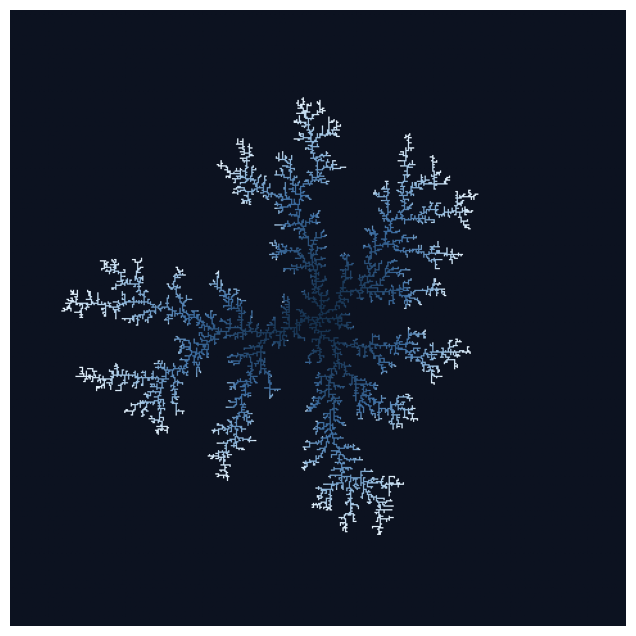

In [6]:
# grow the canonical cluster and color it by age: old core, young tips
from matplotlib.colors import LinearSegmentedColormap, to_rgb

def frost_image(age, colors, background="#0C1220"):
    cmap = LinearSegmentedColormap.from_list("frost", colors)
    grown = age >= 0
    rgb = cmap(age / max(age.max(), 1))[..., :3]   # drop the alpha channel
    rgb[~grown] = to_rgb(background)
    return rgb

ICE = ["#16324F", "#3E6FA3", "#8FB8DC", "#EAF6FF"]

dendrite_age = grow_dla(grid_size=480, n_particles=10000, seed=16)
dendrite = frost_image(dendrite_age, ICE)
print(f"{(dendrite_age >= 0).sum()} particles frozen")

plt.figure(figsize=(8, 8))
plt.imshow(dendrite)
plt.axis("off")
plt.show()

Ten thousand deaths by freezing, about five seconds. Read the colors as a biography: the deep blue core froze first, and every ice-white tip is recent. Notice there is no white anywhere *inside* the cluster. That is the self-reinforcement made visible: once a fjord falls behind, no walker ever reaches its floor again, so growth happens exclusively at the tips. The cluster is all surface and no interior, which is precisely what a fractal dimension of 1.7 will say in numbers in a moment.

**Try it.** Set `crowd=40` and regrow. Faster, but the branches visibly fatten: with that many walkers in flight at once, the fjords no longer starve properly. The crowd dial trades a little physics for a lot of speed, and 4 is our compromise; it is worth seeing what the traded physics *was*.

## The stickiness dial

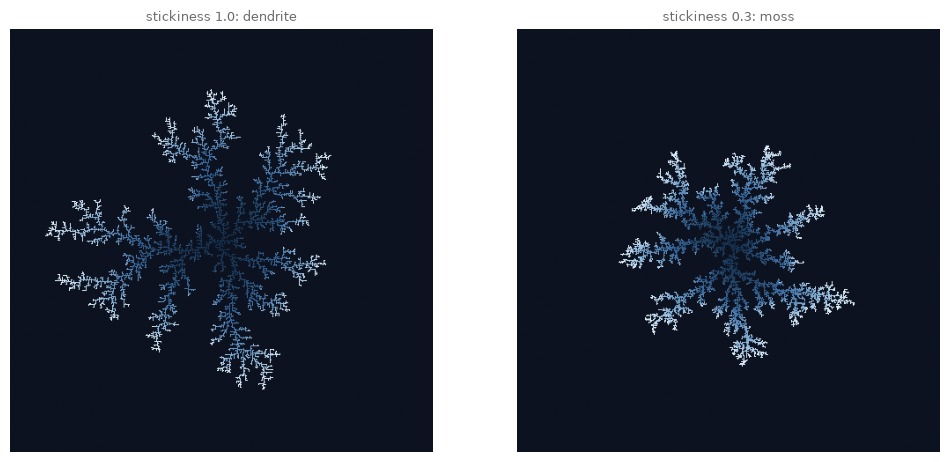

In [7]:
# stickiness 1.0 vs 0.3: wispy dendrite vs dense moss
loose_age = grow_dla(grid_size=480, n_particles=10000, stickiness=0.3, seed=16)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(dendrite)
axes[0].set_title("stickiness 1.0: dendrite", fontsize=9, color="#6B6B6B")
axes[1].imshow(frost_image(loose_age, ICE))
axes[1].set_title("stickiness 0.3: moss", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

Same particle count, different anatomy. At stickiness 0.3 a walker touching a branch usually bounces, slides a little further along it, and catches somewhere deeper; the branches thicken, the fjords partly fill, and the whole cluster contracts (compare the two radii). Low stickiness is a *smoothing* of the growth, and the vocabulary of chapter 14's pattern zoo transfers directly: the dendrite is to the moss what worms are to solid stripes, the same system with its instability turned down.

**Try it.** `stickiness=0.05` grows something close to a furry disc: almost all the branching is gone. Somewhere between 0.05 and 1.0 the transition from *blob* to *dendrite* happens; bracketing it is exercise (a)'s warm-up.

## Measuring the frost

Chapter 8 told the story of fractal dimension twice (Mandelbrot's coastlines, and the Pollock affair) but never measured one. Now we can. Count the frozen particles within distance $r$ of the seed and call it $N(r)$. For a solid disc, $N(r) \propto r^2$; for a straight line of cells, $N(r) \propto r^1$ (read $\propto$ as "grows like", and $N(r)$ as "the count $N$ depends on the radius $r$"). Our frost lives in between:

$$N(r) \propto r^D \qquad\text{so}\qquad \log N(r) = D \log r + \text{const},$$

and $D$ is the **fractal dimension** (fraktale Dimension): on log-log axes (chapter 8's smooth-coloring trick used the same logarithm magic) the mass curve becomes a straight line whose *slope* is $D$. The middle step is chapter 0's logarithm doing its one trick: a logarithm counts doublings, so it turns powers into plain factors, and $\log r^D$ becomes $D \log r$. Straighten a power law with logarithms and the exponent walks out front as the slope of a line; that is the whole magic. `np.polyfit(x, y, 1)` fits that line and hands back the slope.

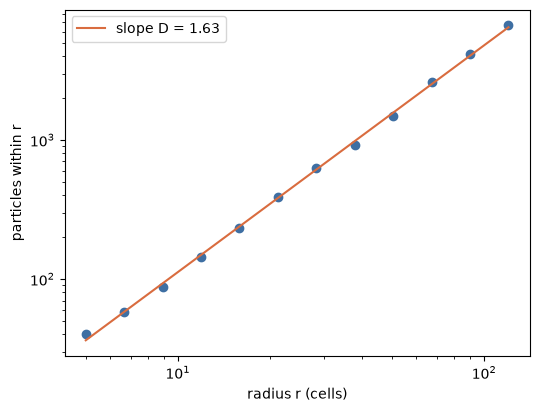

measured dimension: 1.63   (published DLA value: about 1.71)


In [8]:
# mass-radius: count particles within r, fit the log-log slope
center = 240                                   # the grid middle, as in grow_dla
rows, cols = np.nonzero(dendrite_age >= 0)     # coordinates of all frozen cells
dist = np.hypot(rows - center, cols - center)
radii = np.geomspace(5, dist.max() * 0.6, 12)  # like linspace, but multiplicative
mass = np.array([(dist <= r).sum() for r in radii])
D, offset = np.polyfit(np.log(radii), np.log(mass), 1)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(radii, mass, "o", color="#3E6FA3")
# np.exp undoes np.log: e to the offset brings the fit back from log-units
ax.loglog(radii, np.exp(offset) * radii**D, "-", color="#D96C3F",
          label=f"slope D = {D:.2f}")
ax.set_xlabel("radius r (cells)")
ax.set_ylabel("particles within r")
ax.legend()
plt.show()
print(f"measured dimension: {D:.2f}   (published DLA value: about 1.71)")

A straight line on log-log axes across a decade of radii (a decade: one tenfold span, from some $r$ to $10r$), slope around 1.63: our frost is honestly fractal, more than a line and much less than a disc. (We measure below the published 1.713 <a class="cite" href="#ref-davidovitch2000">(Davidovitch et al. 2000)</a>, and should: that value holds for enormous off-lattice clusters, while ours is small, square-gridded, and grown with a crowd. Physicists measuring zinc dendrites in electrochemical cells reported 1.66 <a class="cite" href="#ref-matsushita1984">(Matsushita et al. 1984)</a>, so we are in respectable experimental company. The deviation is itself a lesson: a measured dimension depends on the object's size and on the measuring window.)

Which returns us, armed, to chapter 8's controversy. Richard Taylor and colleagues reported fractal dimensions rising across Pollock's career, up to about 1.7 in the late drip paintings (1.72 for *Blue Poles*) <a class="cite" href="#ref-taylor1999">(Taylor et al. 1999)</a>, numerically right beside the DLA value; <a class="cite" href="#ref-jonessmith2006">Jones-Smith and Mathur (2006)</a> replied that the scaling range in a canvas-sized painting is too narrow for the word "fractal" to carry weight. You have now stood on both sides of that argument: you have grown an object whose dimension is real and measurable across scales, and you have seen how few doublings of $r$ our fit actually spans. The number is easy to produce; the question is always whether the straight line is long enough to mean something.

## Playground: three growths

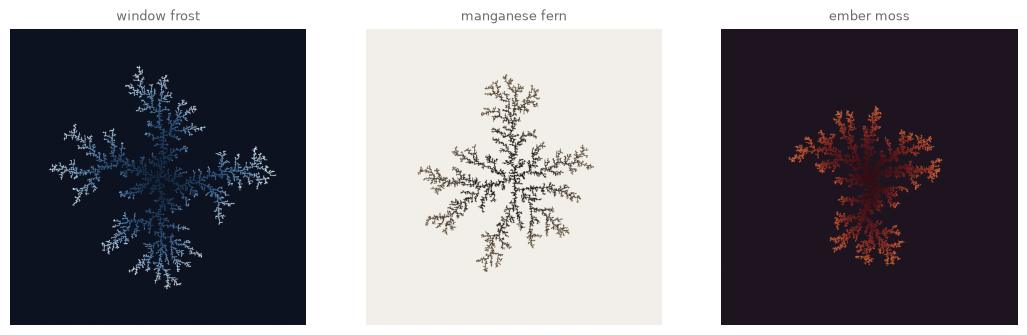

In [9]:
# the same organism in three costumes
MANGANESE = ["#1A1512", "#2E2620", "#4A3D30", "#6B5B45"]
EMBER = ["#3B0A0E", "#701C1C", "#A63A22", "#D96C3F"]

pieces = [
    (grow_dla(n_particles=10000, seed=7), ICE, "#0C1220", "window frost"),
    (grow_dla(n_particles=10000, stickiness=0.5, seed=3), MANGANESE, "#F2EFE9",
     "manganese fern"),
    (grow_dla(n_particles=10000, stickiness=0.25, seed=11), EMBER, "#1E1420",
     "ember moss"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (piece_age, colors, ground, title) in zip(axes, pieces):
    ax.imshow(frost_image(piece_age, colors, background=ground))
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** The ice cluster reads as winter, the brown one on paper as a Solnhofen pseudofossil, the ember one as lichen on dark stone, and yet all three are the same organism with different stickiness and clothes. Which of the two dials, stickiness or palette, does more to change what the thing *is*? Chapter 6 argued that color is never mere decoration; this triptych is that argument compressed.

## Export your artwork

Grow your own: pick particle count, stickiness, palette, ground, seed. `np.kron` (chapter 13's enlarger) lifts the 480-cell grid to print size with every frozen cell kept as a crisp square. Replace `yourname` and run.

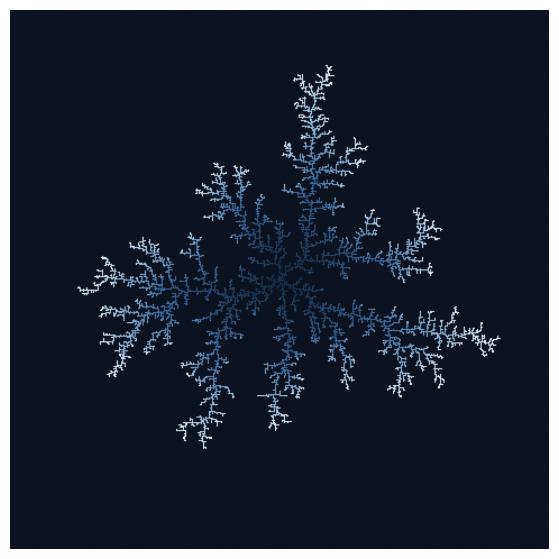

saved: assets/outputs/ch20_yourname.png


In [10]:
# save YOUR artwork: grow, dress, enlarge, replace 'yourname'
import sys
sys.path.append("..")
from agap.helpers import save_artwork, show

my_age = grow_dla(n_particles=10000, stickiness=1.0, seed=41)
my_artwork = np.kron(frost_image(my_age, ICE), np.ones((5, 5, 1)))
show(my_artwork)
saved_path = save_artwork(my_artwork, "yourname", chapter=20)

## Exercises

**(a) Parameter exploration: the anatomy of stickiness.** Grow clusters at stickiness 1.0, 0.6, 0.3, 0.15 and 0.05 (same seed, same particle count) and describe the sequence in the vocabulary of chapter 14's pattern zoo: where does *dendrite* become *moss*, where does *moss* become *blob*? Then check your morphology reading against arithmetic: measure $D$ for each (the fit cell works unchanged on any `age` grid) and watch the dimension climb toward 2 as the branching dies.

**(b) Code modification: frost on a twig.** Replace the single-cell seed with a horizontal bar: build the row and column arrays for a 120-cell line through the center and pass them as `seed_cells`. The frost stops being a star and becomes fur on a twig, the same anatomy growing from a different beginning. (This is why the engine measures its starting radius from the seed cells instead of assuming 1.)

<details><summary>Solution</summary>

```python
bar_rows = np.full(120, 240)             # 120 cells, all on the center row
bar_cols = np.arange(240 - 60, 240 + 60)
twig_age = grow_dla(n_particles=9000, seed_cells=(bar_rows, bar_cols), seed=16)
show(frost_image(twig_age, ICE))
```

The paired arrays are chapter 15's indexing idiom: cell (240, 180), cell (240, 181), and so on. Every part of the machinery (birth ring, kill ring, dilation) works unchanged because none of it ever assumed the seed was a point; only the initial `radius` had to be honest about where the frost already reaches.
</details>

**(c) Creative challenge: frost inside a figure.** Give the engine a *territory*: an `allowed` boolean grid (say, the thresholded silhouette of an artwork, built with chapter 15's darkness machinery), and modify `grow_dla` so walkers that step outside the territory are respawned and nothing freezes beyond it, then seed somewhere inside. Two or three lines per rule: one respawn line right after the `lost` respawn, one extra `&` on the `touching` line. The frost will grow to fill the figure and stop at its skin, a portrait drawn entirely by refusal. Name the piece and bring it to the gallery.

## Further reading

- Philip Ball, *Branches* (Oxford University Press, 2009): the branching volume of his *Nature's Patterns* trilogy; snowflakes, mineral dendrites, DLA and dielectric breakdown, written for readers of images.
- W. A. Bentley and W. J. Humphreys, *Snow Crystals* (McGraw-Hill, 1931; Dover reprint 1962): the catalogue itself; hundreds of Bentley's photographs are also freely viewable via the Smithsonian Institution Archives.
- T. A. Witten and L. M. Sander, "Diffusion-Limited Aggregation, a Kinetic Critical Phenomenon", *Physical Review Letters* 47 (1981): the four pages that started the field.
- Kenneth Libbrecht, snowcrystals.com: a Caltech physicist's free site on how real snow crystals grow, where the ice lattice adds what DLA alone cannot.

## References

- <span id="ref-ball2009"></span>Ball, P. (2009). *Branches* (Nature's Patterns: A Tapestry in Three Parts). Oxford University Press. Surveys the whole family of DLA-like growths: electrodeposits, viscous fingers, dielectric breakdown, mineral dendrites.
- <span id="ref-bentley1931"></span>Bentley, W. A., and Humphreys, W. J. (1931). *Snow Crystals*. McGraw-Hill (Dover reprint 1962). The catalogue itself: about 2,450 of Bentley's photomicrographs.
- <span id="ref-blanchard1998"></span>Blanchard, D. C. (1998). *The Snowflake Man: A Biography of Wilson A. Bentley*. McDonald and Woodward. The standard biography, from the first successful photomicrograph of 15 January 1885 to Bentley's death in December 1931.
- <span id="ref-chopard1991"></span>Chopard, B., Herrmann, H. J., and Vicsek, T. (1991). Structure and growth mechanism of mineral dendrites. *Nature*, 353, 409–412. [doi:10.1038/353409a0](https://doi.org/10.1038/353409a0). The physics of the branching manganese and iron oxide deposits on limestone surfaces.
- <span id="ref-davidovitch2000"></span>Davidovitch, B., Levermann, A., and Procaccia, I. (2000). Convergent calculation of the asymptotic dimension of diffusion limited aggregates: Scaling and renormalization of small clusters. *Physical Review E*, 62(6), R5919–R5922. [doi:10.1103/PhysRevE.62.R5919](https://doi.org/10.1103/PhysRevE.62.R5919). The source of the asymptotic value D = 1.713 ± 0.003 for off-lattice DLA.
- <span id="ref-jonessmith2006"></span>Jones-Smith, K., and Mathur, H. (2006). Fractal analysis: Revisiting Pollock's drip paintings. *Nature*, 444, E9–E10. [doi:10.1038/nature05398](https://doi.org/10.1038/nature05398). The reply arguing that the scaling range in a canvas-sized painting is too narrow for the word "fractal".
- <span id="ref-libbrecht2005"></span>Libbrecht, K. G. (2005). The physics of snow crystals. *Reports on Progress in Physics*, 68(4), 855–895. [doi:10.1088/0034-4885/68/4/R03](https://doi.org/10.1088/0034-4885/68/4/R03). How the ice lattice adds the six-fold symmetry that DLA alone cannot supply.
- <span id="ref-matsushita1984"></span>Matsushita, M., Sano, M., Hayakawa, Y., Honjo, H., and Sawada, Y. (1984). Fractal structures of zinc metal leaves grown by electrodeposition. *Physical Review Letters*, 53(3), 286–289. [doi:10.1103/PhysRevLett.53.286](https://doi.org/10.1103/PhysRevLett.53.286). The zinc dendrites measured at D = 1.66 ± 0.03.
- <span id="ref-takahashi1979"></span>Takahashi, Y. (1979). Two hundred years of Lichtenberg figures. *Journal of Electrostatics*, 6(1), 1–13. [doi:10.1016/0304-3886(79)90020-2](https://doi.org/10.1016/0304-3886(79)90020-2). The history of the figures from Lichtenberg's 1777 discovery in Göttingen onward.
- <span id="ref-taylor1999"></span>Taylor, R. P., Micolich, A. P., and Jonas, D. (1999). Fractal analysis of Pollock's drip paintings. *Nature*, 399, 422. [doi:10.1038/20833](https://doi.org/10.1038/20833). Reports fractal dimensions rising across Pollock's career, up to 1.72 for *Blue Poles*.
- <span id="ref-wilson2013"></span>Wilson, M. A. (2013). Wooster's pseudofossil of the week: Manganese dendrites from Germany. *Wooster Geologists*, The College of Wooster, 20 January 2013. [woostergeologists.scotblogs.wooster.edu](https://woostergeologists.scotblogs.wooster.edu/2013/01/20/woosters-pseudofossil-of-the-week-manganese-dendrites-from-the-germany/). A paleontologist on the Solnhofen dendrites that "may look like fossil fern".
- <span id="ref-witten1981"></span>Witten, T. A., and Sander, L. M. (1981). Diffusion-limited aggregation, a kinetic critical phenomenon. *Physical Review Letters*, 47(19), 1400–1403. [doi:10.1103/PhysRevLett.47.1400](https://doi.org/10.1103/PhysRevLett.47.1400). The four pages that started the field.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: a larger canvas, eighteen thousand particles, the ice palette, about twenty seconds of freezing. Raise `n_particles` and `grid_size` together at home for a poster-sized dendrite (they trade runtime for reach). It runs automatically with *Restart & Run All*.

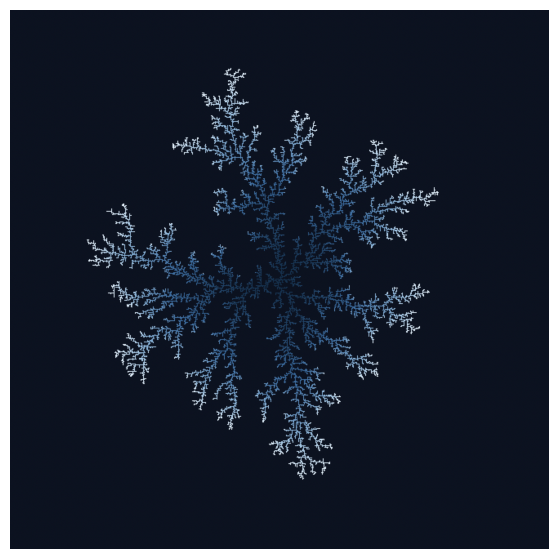

saved: assets/outputs/ch20_showpiece.png


In [11]:
# regenerate this chapter's showpiece: the great dendrite, aged in ice
showpiece_age = grow_dla(grid_size=660, n_particles=18000, seed=16)
showpiece = np.kron(frost_image(showpiece_age, ICE), np.ones((4, 4, 1)))
show(showpiece)
saved_path = save_artwork(showpiece, "showpiece", chapter=20)